In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import trimesh

In [2]:
# TPC boundaries (cm)
tpcMinX = -200
tpcMaxX = 200
tpcMinY = -200
tpcMaxY = 200
tpcMinZ = 0
tpcMaxZ = 500
tpcProjZFront = tpcMinZ

'''
# Fiducial volume boundaries (cm)
tpcMinX = -183.5
tpcMaxX = 183.5
tpcMinY = -185
tpcMaxY = 185
tpcMinZ = 40 # start of the fiducial volume, where 0 is the front face of the tpc
tpcMaxZ = 460
tpcProjZFront = 0
'''
# Beam center (cm)
beamCenterX = -74
beamCenterY = 0
beamCenterZ = 11000 # front face of the tpc, where 0 is the beam target

In [3]:
# Plot settings
colorTot = 'C3'; colorP = 'C0'; colorNP = 'C1'
ylimit = (0,)
xlimit=(0,)
erAlpha = 0.3

nbins = np.arange(0, 4.1, .2)
nbinsTPC = np.arange(0, 1.81, .2)

In [4]:
# exact volume normalization
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, (tpcMaxZ-tpcMinZ)/200])
norm_vols = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cone = trimesh.creation.cone(radius=radius, height=((beamCenterZ+tpcMaxZ)/100))
    vol = cone.volume - cone.difference(tpcBox).volume
    if i > 0:
        vol -= np.sum(norm_vols[0:i])
    if vol < 1e-5:
        vol = 0
    norm_vols = np.append(norm_vols, vol)
norm_vols

array([ 2.40724613,  7.22197472, 12.03740189, 14.91265475, 16.34991851,
       12.68422353,  8.99719651,  4.62961908,  0.75974863])

In [5]:
# Front face normalization v1
norm_areas = np.array([])
r1 = min(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m
r2 = min(abs(tpcMinY - beamCenterY)/100, abs(tpcMaxY - beamCenterY)/100)  # m
r4 = max(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    area = np.pi * radius**2
    if i > 0:
        if radius > r1:
            area -= quad(lambda x: 2*np.sqrt(radius**2 - x**2), r1, radius)[0]
        if radius > r2:
            area -= quad(lambda y: 4*np.sqrt(radius**2 - y**2), r2, radius)[0]
        if radius > np.sqrt(r1**2 + r2**2):
            area += quad(lambda x1: 2*(np.sqrt(radius**2 - x1**2) - 2), r1, np.sqrt(radius**2 - r2**2))[0]
        if radius > r4:
            area -= quad(lambda z: 2*np.sqrt(radius**2 - z**2), r4, radius)[0]
        if radius > np.sqrt(r4**2 + r2**2):
            area += quad(lambda x2: 2*(np.sqrt(radius**2 - x2**2) - r2), r4, np.sqrt(radius**2 - r2**2))[0]
        area -= np.sum(norm_areas[0:i])
    if area < 1e-5:
        area = 0
    norm_areas = np.append(norm_areas, area)
norm_areas

array([0.46318395, 1.38959699, 2.31614549, 2.91337013, 3.17304591,
       2.64577569, 1.79511938, 1.07684058, 0.22692188])

In [6]:
# front face normalization v2
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_area_front = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cylinder = trimesh.creation.cylinder(radius=radius, height=1)
    vol_front = cylinder.volume - cylinder.difference(tpcBox).volume
    if i > 0:
        vol_front -= np.sum(norm_area_front[0:i])
    if vol_front < 1e-5:
        vol_front = 0
    norm_area_front = np.append(norm_area_front, vol_front)
norm_area_front

array([0.46021348, 1.38068529, 2.3012917 , 2.90156067, 3.15716035,
       2.66261935, 1.79451502, 1.0987741 , 0.24318045])

In [7]:
# front face normalization v3
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_area_front3 = np.array([])
for i in range(len(nbinsTPC)-1):
    rmin = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i] * np.pi / 180)
    radius = ((beamCenterZ+tpcProjZFront)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    annulus = trimesh.creation.annulus(r_min=rmin, r_max=radius, height=1)
    vol_front3 = annulus.volume - annulus.difference(tpcBox).volume
    if vol_front3 < 1e-5:
        vol_front3 = 0
    norm_area_front3 = np.append(norm_area_front3, vol_front3)
norm_area_front3

array([0.46021348, 1.38068529, 2.3012917 , 2.90156067, 3.15716035,
       2.66261935, 1.79451502, 1.0987741 , 0.24318045])

In [8]:
# back face normalization
tpcBox = trimesh.creation.box(extents=[(tpcMaxX-tpcMinX)/100, (tpcMaxY-tpcMinY)/100, (tpcMaxZ-tpcMinZ)/100])
tpcBox.apply_translation([beamCenterX/100, beamCenterY/100, 0])
norm_area_back = np.array([])
for i in range(len(nbinsTPC)-1):
    radius = ((beamCenterZ+tpcMaxZ)/100) * np.tan(nbinsTPC[i+1] * np.pi / 180)
    cylinder_back = trimesh.creation.cylinder(radius=radius, height=1)
    vol_back = cylinder_back.volume - cylinder_back.difference(tpcBox).volume
    if i > 0:
        vol_back -= np.sum(norm_area_back[0:i])
    if vol_back < 1e-5:
        vol_back = 0
    norm_area_back = np.append(norm_area_back, vol_back)
norm_area_back

array([0.50300192, 1.50905479, 2.51525478, 3.06264713, 3.38341498,
       2.39970571, 1.78209747, 0.76804313, 0.07677968])

In [9]:
r1 = min(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m
r2 = min(abs(tpcMinY - beamCenterY)/100, abs(tpcMaxY - beamCenterY)/100)  # m
r3 = max(abs(tpcMinY - beamCenterY)/100, abs(tpcMaxY - beamCenterY)/100)  # m
r4 = max(abs(tpcMinX - beamCenterX)/100, abs(tpcMaxX - beamCenterX)/100)  # m

def subPerimeter(outerR, innerR, boundary, smallCorner, bigCorner):
    assert smallCorner <= bigCorner, "smallCorner must be less than or equal to bigCorner"
    assert smallCorner > boundary, "smallCorner must be bigger than distance to boundary"
    if outerR <= boundary or innerR > bigCorner:
        return 0
    if outerR <= smallCorner and innerR <= boundary:
        return 2*np.sqrt(outerR**2 - boundary**2)
    if outerR <= smallCorner and innerR > boundary and innerR <= smallCorner:
        return 2*(np.sqrt(outerR**2 - boundary**2) - np.sqrt(innerR**2 - boundary**2))
    if outerR > smallCorner and outerR <= bigCorner and innerR <= boundary:
        return np.sqrt(outerR**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2)
    if outerR > bigCorner and innerR <= boundary:
        return np.sqrt(bigCorner**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2)
    if outerR > smallCorner and outerR <= bigCorner and innerR > boundary and innerR <= smallCorner:
        return np.sqrt(outerR**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2) - 2*np.sqrt(innerR**2 - boundary**2)
    if outerR > bigCorner and innerR > boundary and innerR <= smallCorner:
        return np.sqrt(bigCorner**2 - boundary**2) + np.sqrt(smallCorner**2 - boundary**2) - 2*np.sqrt(innerR**2 - boundary**2)
    if outerR > smallCorner and outerR <= bigCorner and innerR > smallCorner and innerR <= bigCorner:
        return np.sqrt(outerR**2 - boundary**2) - np.sqrt(innerR**2 - boundary**2)
    if outerR > bigCorner and innerR > smallCorner and innerR <= bigCorner:
        return np.sqrt(bigCorner**2 - boundary**2) - np.sqrt(innerR**2 - boundary**2)
    return -1        

def getPerimeterFront(outerAngle, innerAngle):
    r_max = ((beamCenterZ+tpcProjZFront)/100) * np.tan(outerAngle * np.pi / 180)
    r_min = ((beamCenterZ+tpcProjZFront)/100) * np.tan(innerAngle * np.pi / 180)
    perimeter = 0
    perimeter += subPerimeter(r_max, r_min, r1, np.sqrt(r1**2+r2**2), np.sqrt(r1**2+r3**2))
    perimeter += subPerimeter(r_max, r_min, r2, np.sqrt(r1**2+r2**2), np.sqrt(r4**2+r2**2))
    perimeter += subPerimeter(r_max, r_min, r3, np.sqrt(r1**2+r3**2), np.sqrt(r4**2+r3**2))
    perimeter += subPerimeter(r_max, r_min, r4, np.sqrt(r4**2+r2**2), np.sqrt(r4**2+r3**2))
    return perimeter

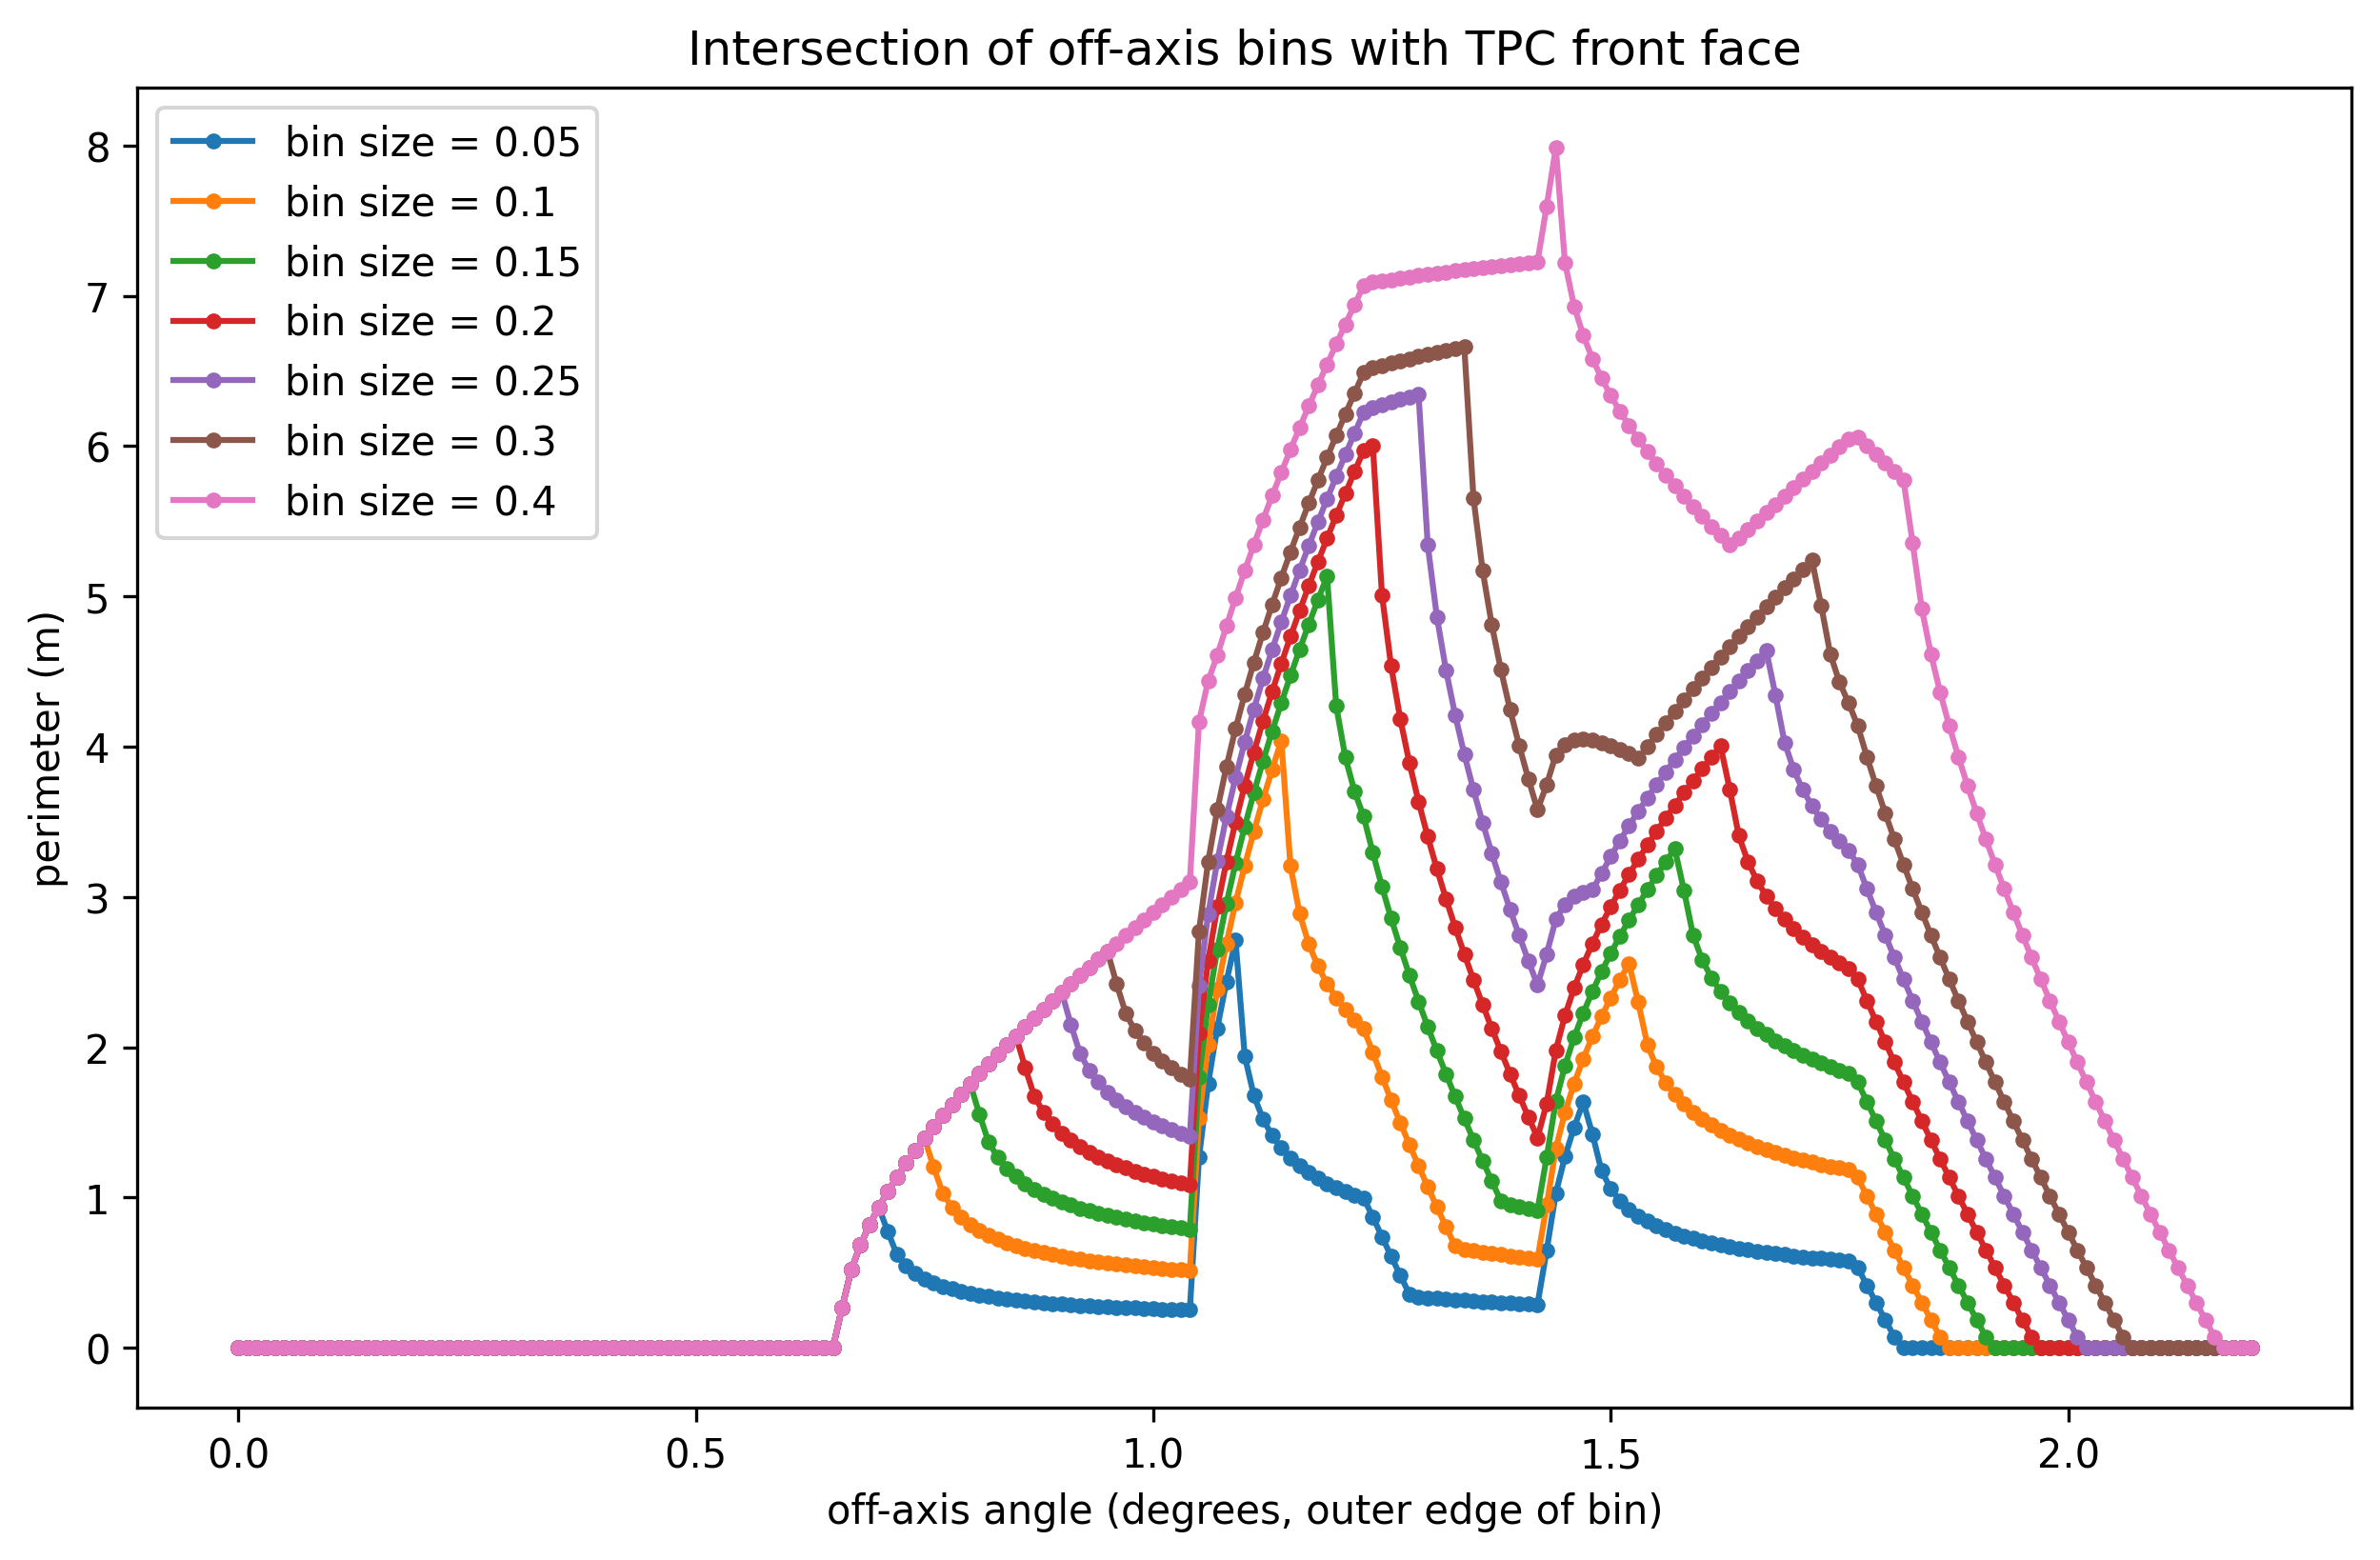

In [10]:
angleSpace = np.arange(0, 2.200001, 0.01)
binnings = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4])
plt.figure(figsize=(10, 6), dpi=300)
for b in binnings:
    perms = np.array([])
    for a in angleSpace:
        if a < b:
            perms = np.append(perms, 0)
        else:
            perms = np.append(perms, getPerimeterFront(a, a-b))
    plt.plot(angleSpace, perms, label=f'bin size = {b}', marker='.')
plt.legend()
plt.xlabel('off-axis angle (degrees, outer edge of bin)')
plt.ylabel('perimeter (m)')
plt.title('Intersection of off-axis bins with TPC front face')
plt.show()